In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:\\Data Sets\\Player.csv")
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      263 non-null    f

In [4]:
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [5]:
df.shape

(322, 21)

In [6]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns
print(f"numerical cols: {numerical_cols}")
print(f"categorical cols: {categorical_cols}")

numerical cols: Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'Salary'],
      dtype='object')
categorical cols: Index(['Unnamed: 0', 'League', 'Division', 'NewLeague'], dtype='object')


In [7]:
for col in numerical_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      322 non-null    f

In [9]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [10]:
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,11,293,66,1,30,29,14,1,293,66,...,30,29,14,0,0,446,33,20,425.0,0
1,1,315,81,7,24,38,39,14,3449,835,...,321,414,375,1,1,632,43,10,475.0,1
2,6,479,130,18,66,72,76,3,1624,457,...,224,266,263,0,1,880,82,14,480.0,0
3,7,496,141,20,65,78,37,11,5628,1575,...,828,838,354,1,0,200,11,3,500.0,1
4,9,321,87,10,39,42,30,2,396,101,...,48,46,33,1,0,805,40,4,91.5,1


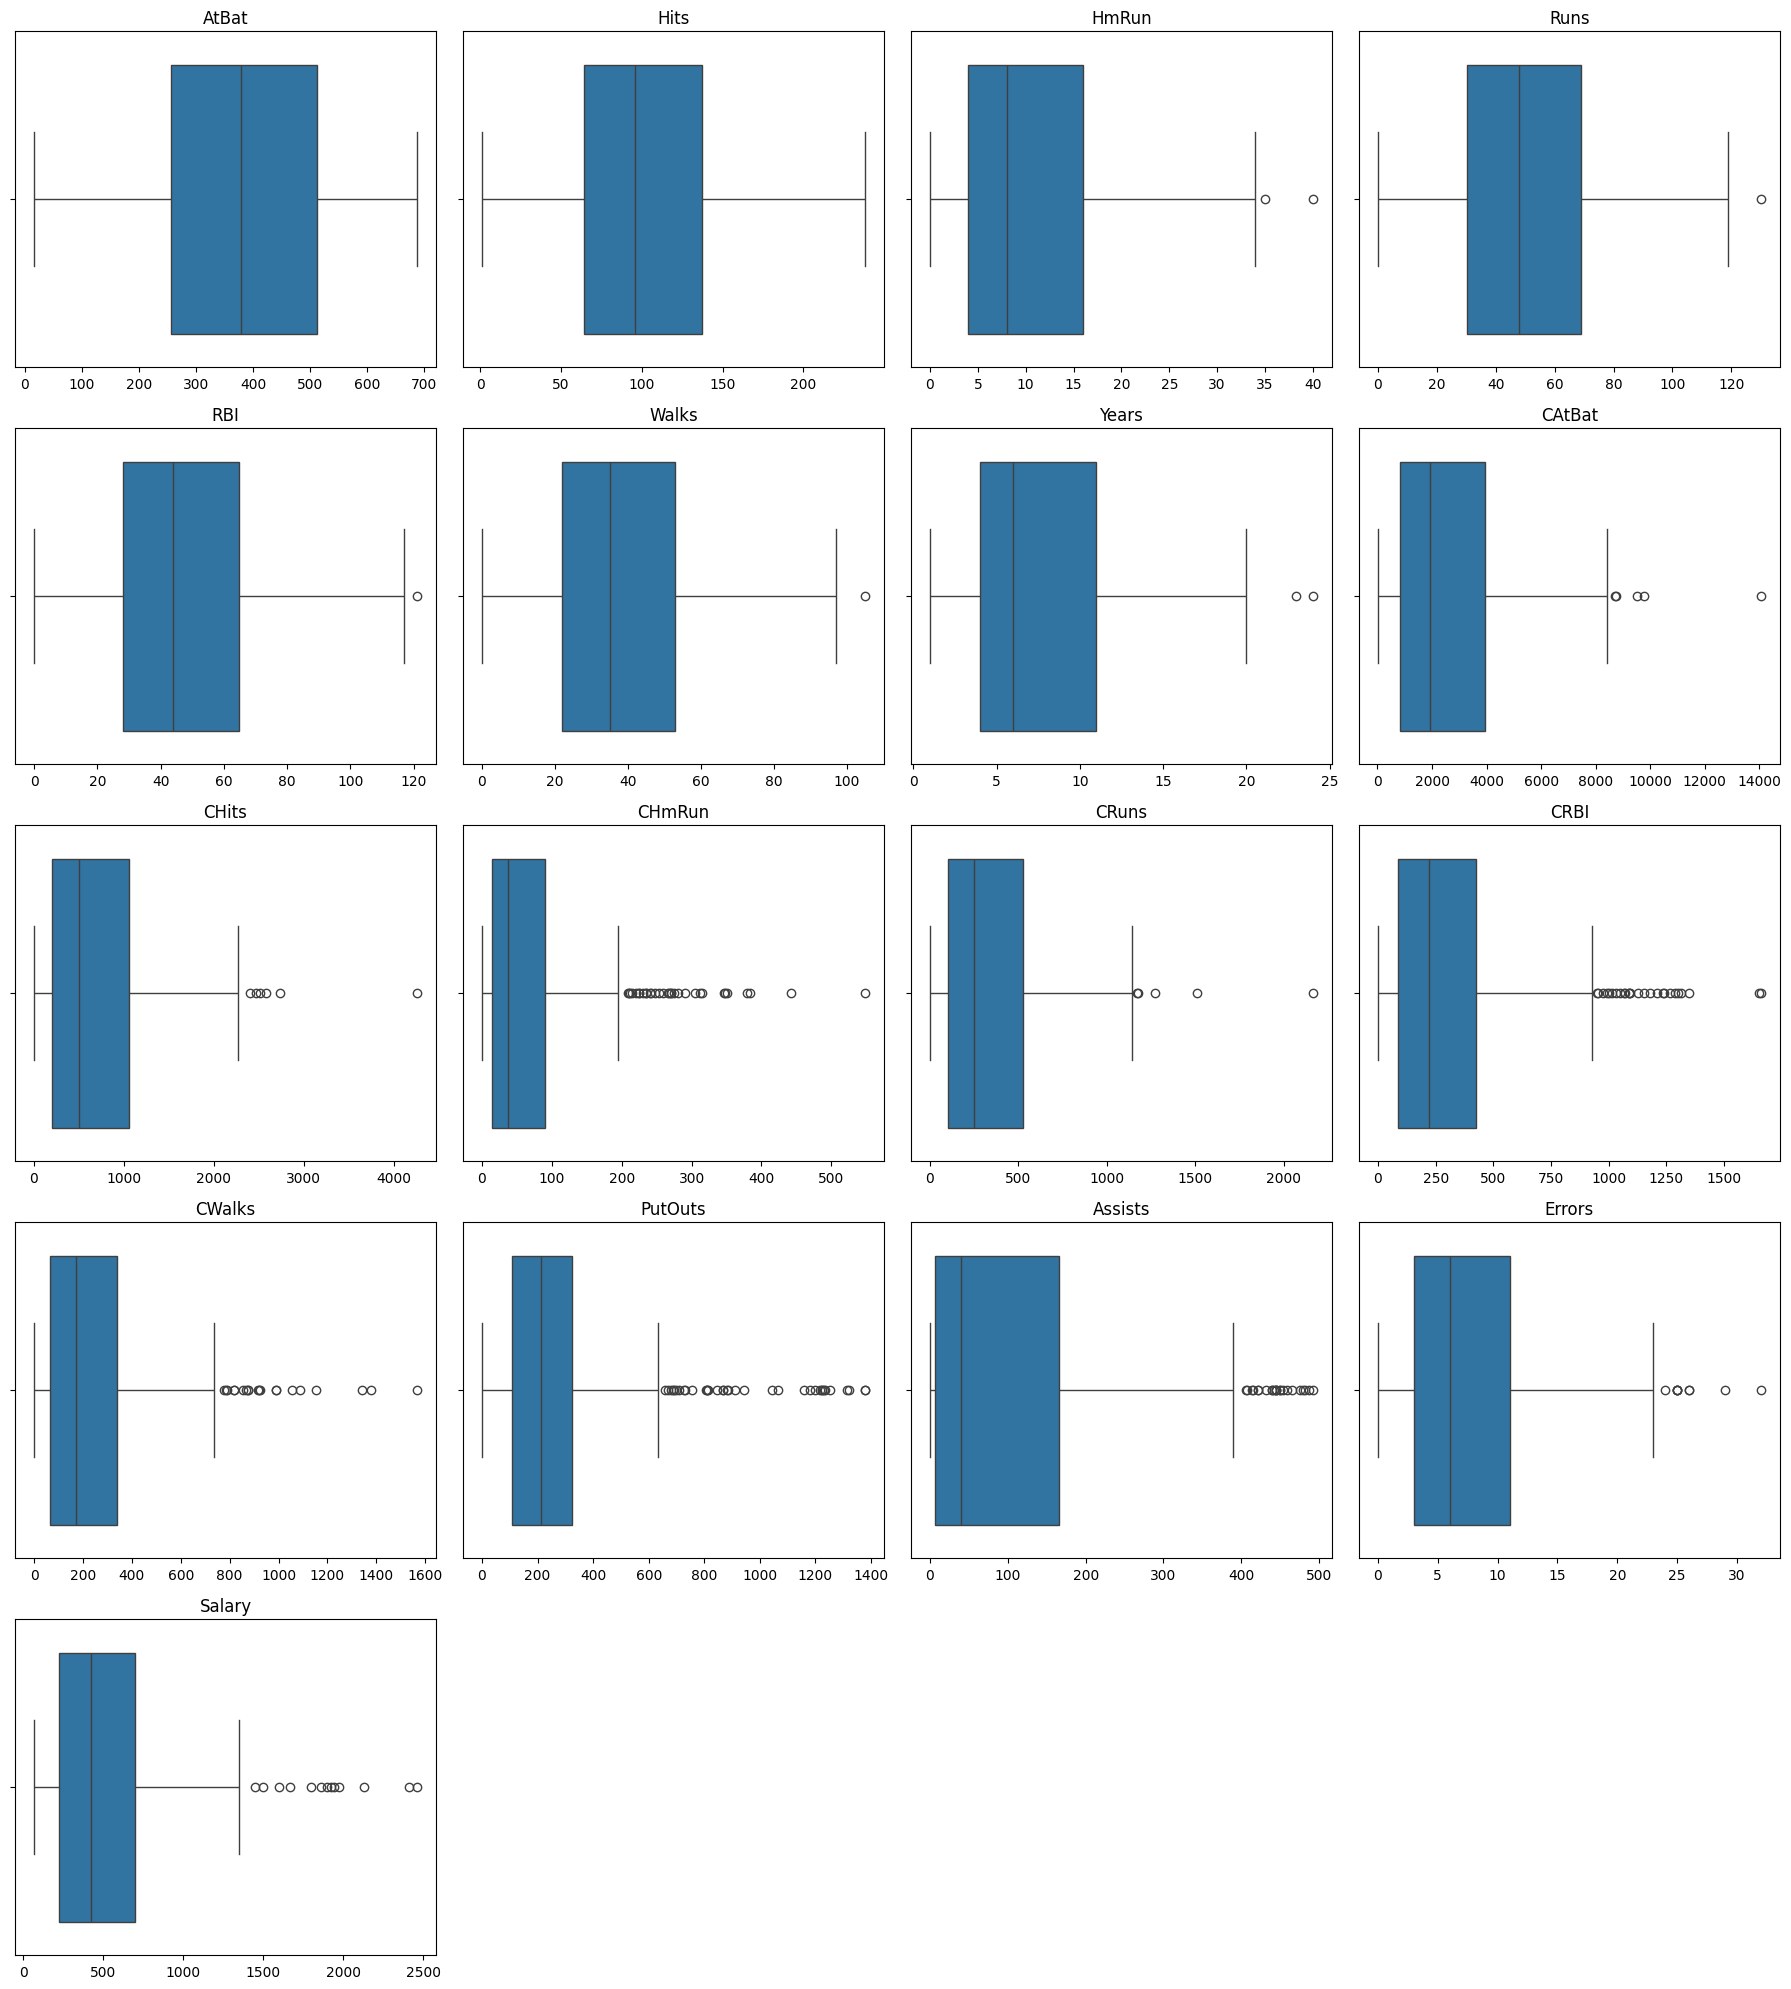

In [11]:
num_features = len(numerical_cols)
cols = 4
rows = math.ceil(num_features / cols)

plt.figure(figsize=(18, 4 * rows))

for idx, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, idx)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.xlabel("")

for idx in range(num_features + 1, rows * cols + 1):
    plt.subplot(rows, cols, idx)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

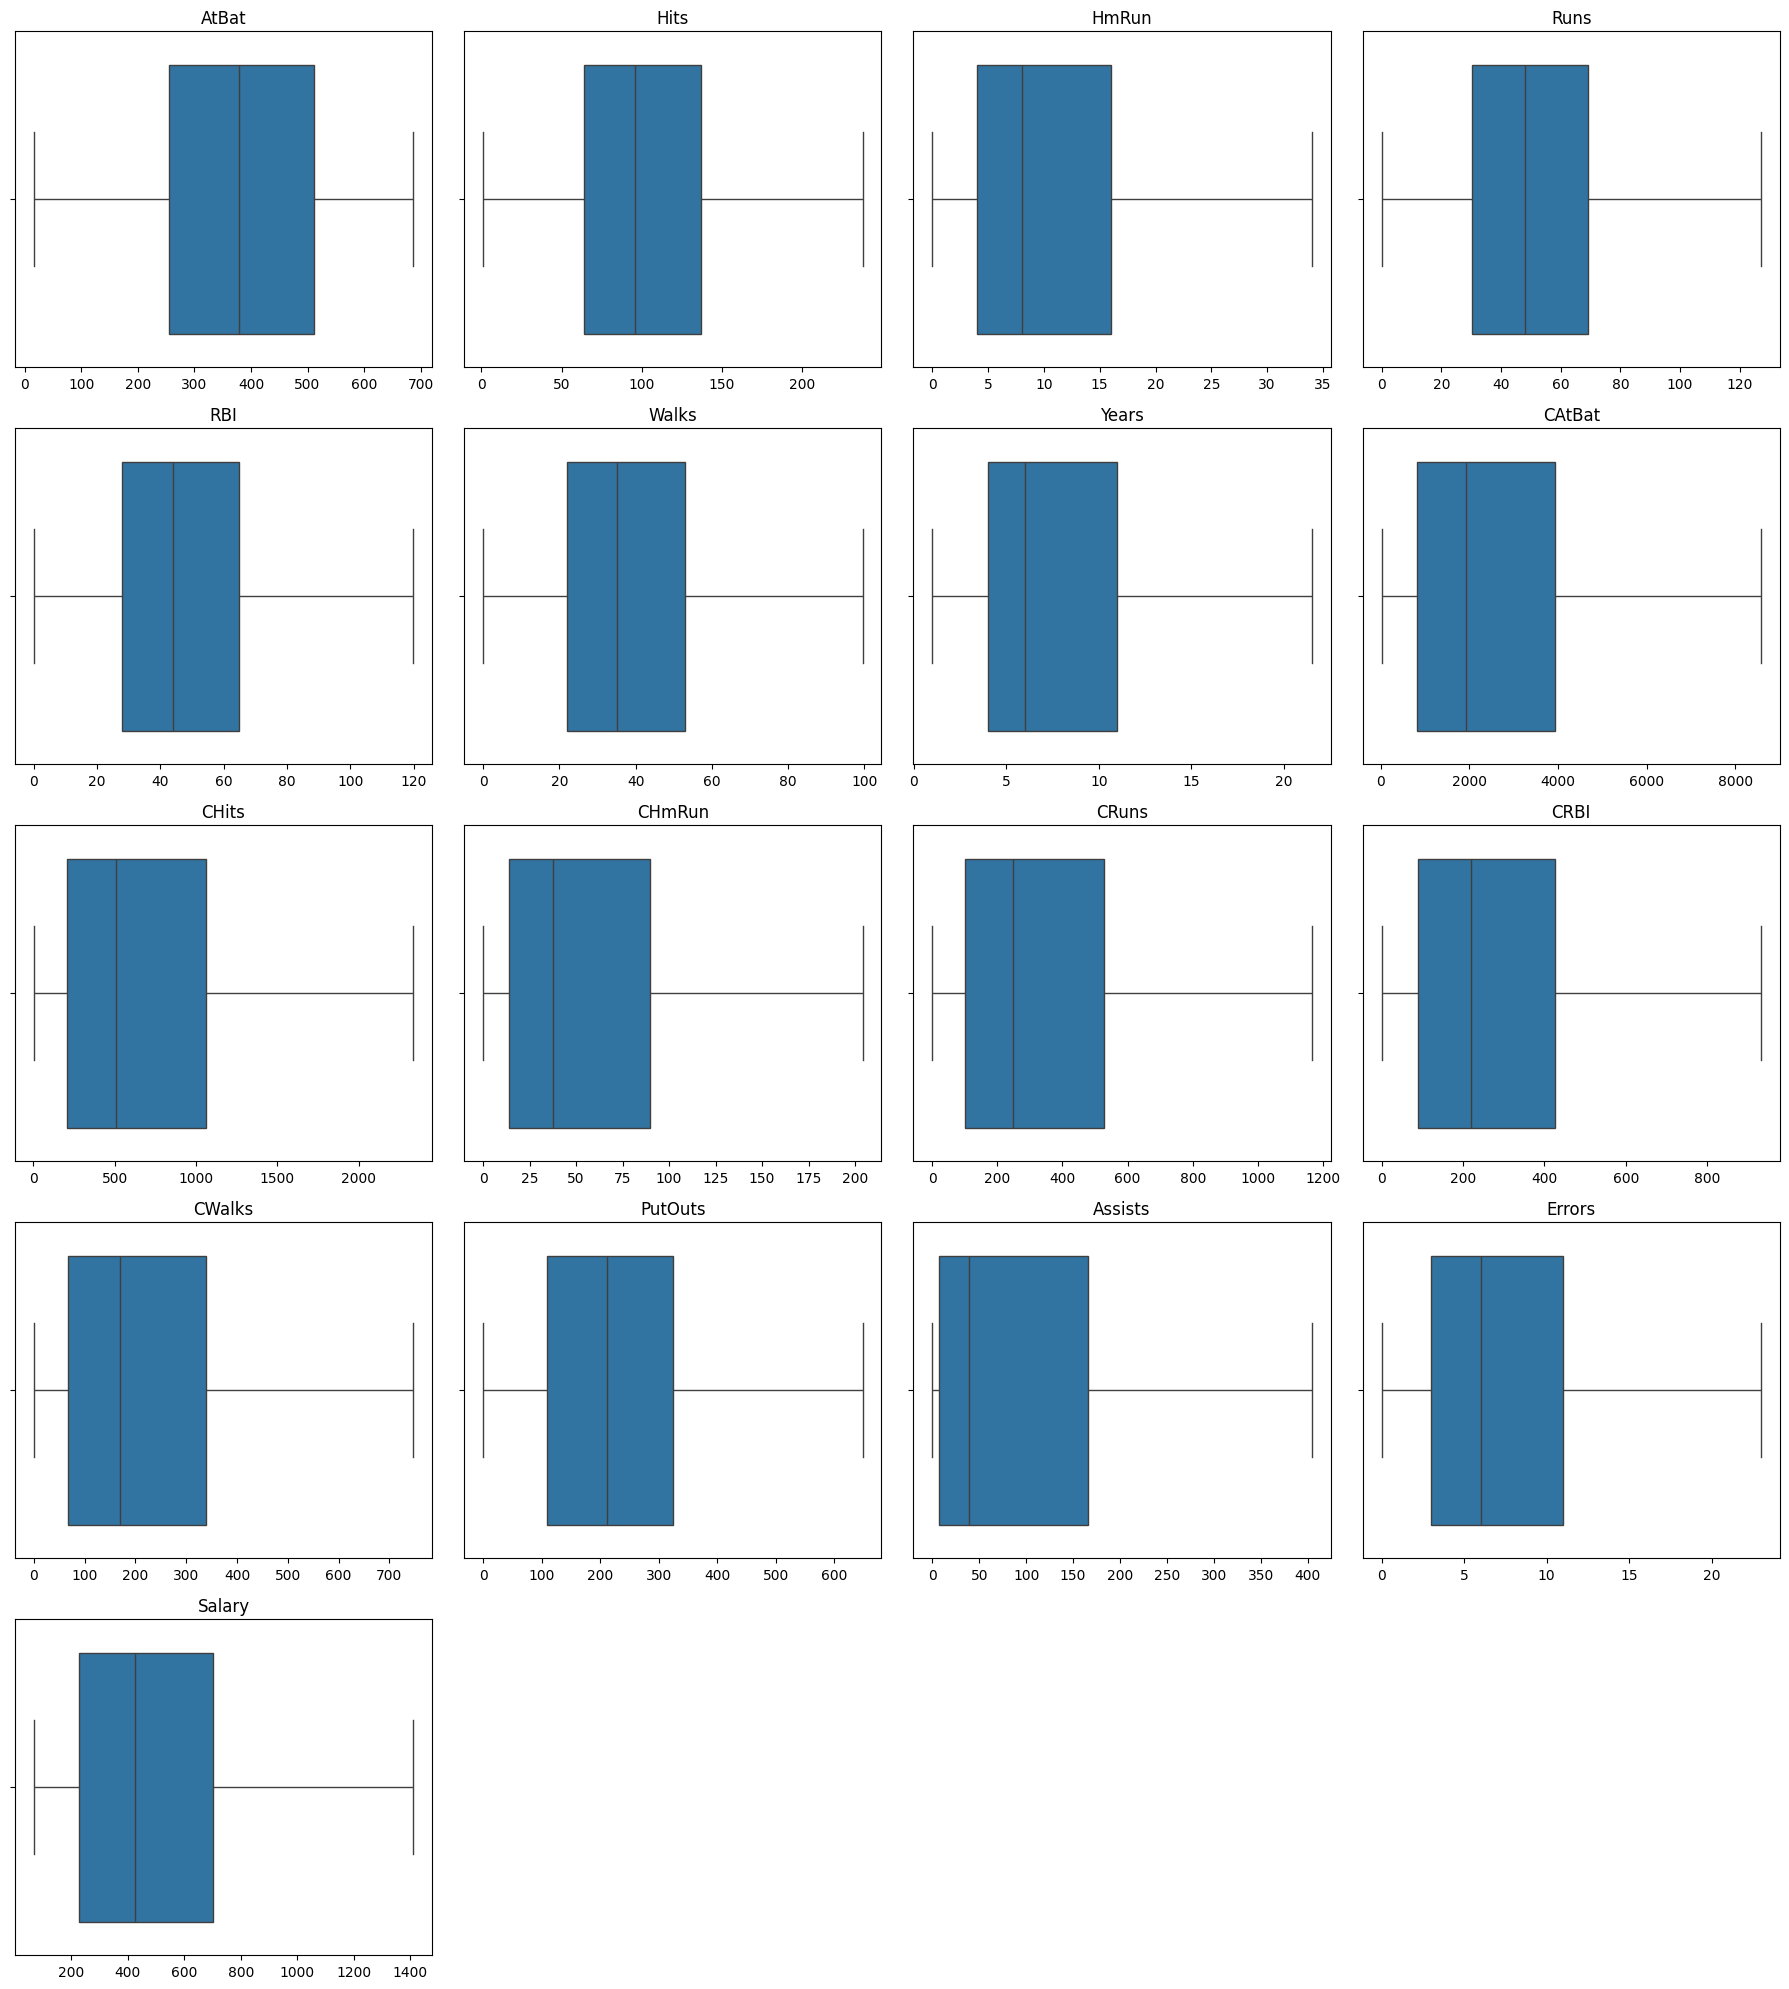

In [13]:
num_features = len(numerical_cols)
cols = 4
rows = math.ceil(num_features / cols)

plt.figure(figsize=(18, 4 * rows))

for idx, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, idx)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.xlabel("")

for idx in range(num_features + 1, rows * cols + 1):
    plt.subplot(rows, cols, idx)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

## Ridge

In [15]:
alphas = 10**np.linspace(10,-2,100)*0.00001
ridge = Ridge()
coeffs = []

In [16]:
sc = StandardScaler()
for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(sc.fit_transform(X), y)
    coeffs.append(ridge.coef_)
np.shape(coeffs)

(100, 20)

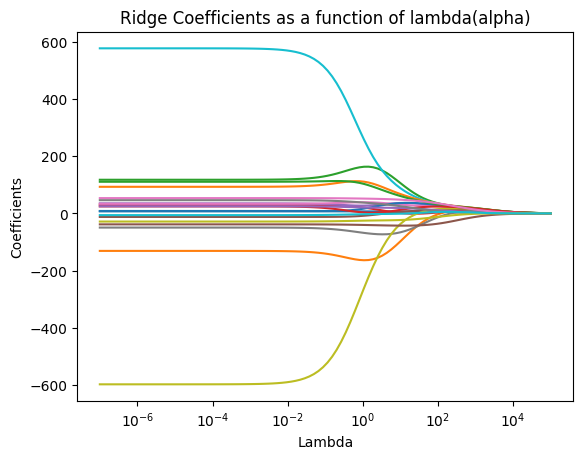

In [17]:
ax = plt.gca()
ax.plot(alphas, coeffs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('Lambda')
plt.ylabel('Coefficients')
plt.title('Ridge Coefficients as a function of lambda(alpha)')
plt.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
def Ridge_Regression(alpha):
    sc = StandardScaler()
    ridge = Ridge(alpha=alpha)
    ridge.fit(sc.fit_transform(X_train), y_train)
    y_pred = ridge.predict(sc.transform(X_test))
    print(pd.Series(ridge.coef_, index=X.columns))
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))

In [20]:
Ridge_Regression(20)

Unnamed: 0    18.270836
AtBat        -56.337720
Hits          72.524477
HmRun         -3.842963
Runs          24.272147
RBI            5.399081
Walks         22.177129
Years        -54.078287
CAtBat       -11.221735
CHits         72.094335
CHmRun        61.274602
CRuns         49.075747
CRBI          54.574772
CWalks         4.293230
League        24.820845
Division     -36.773212
PutOuts       40.660070
Assists       13.281931
Errors       -15.623068
NewLeague     -5.256830
dtype: float64
Mean Squared Error: 63352.713919484755
R2 Score: 0.45202118668178537


In [21]:
sc = StandardScaler()
ridgecv = RidgeCV(alphas=alphas, cv=20)
ridgecv.fit(sc.fit_transform(X_train), y_train)
ridgecv.alpha_

np.float64(93.26033468832199)

In [22]:
sc = StandardScaler()
opt_ridge = Ridge(alpha=ridgecv.alpha_)
opt_ridge.fit(sc.fit_transform(X_train), y_train)
pred = opt_ridge.predict(sc.transform(X_test))
mean_squared_error(y_test, pred)

63395.43856984862

## Lasso

In [23]:
lasso = Lasso()
coefs = []

In [24]:
sc = StandardScaler()
for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(sc.fit_transform(X), y)
    coefs.append(lasso.coef_)
np.shape(coefs)

(100, 20)

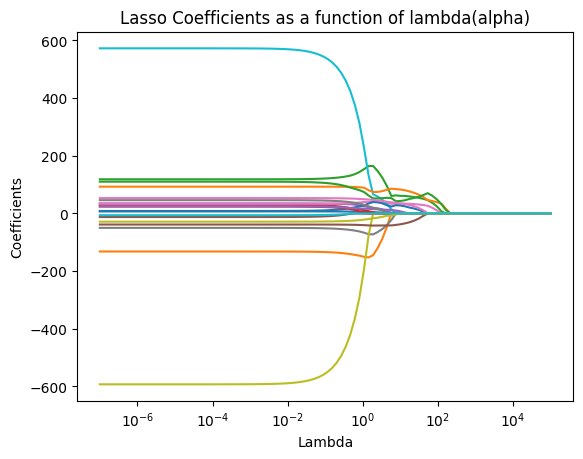

In [25]:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('Lambda')
plt.ylabel('Coefficients')
plt.title('Lasso Coefficients as a function of lambda(alpha)')
plt.show()

In [26]:
lassocv = LassoCV(alphas=None, cv=10, max_iter=100000)
lassocv.fit(sc.fit_transform(X_train), y_train)
LassoCV(cv=10, max_iter=100000)
lassocv.alpha_

np.float64(0.8006037208766342)

In [27]:
lasso.set_params(alpha=lassocv.alpha_)
lasso.fit(sc.fit_transform(X_train), y_train)
mean_squared_error(y_test, lasso.predict(sc.transform(X_test)))

71651.65496154345

In [28]:
pd.Series(lasso.coef_, index=X.columns)

Unnamed: 0     20.199927
AtBat        -113.286396
Hits           93.571602
HmRun          15.530187
Runs           36.785946
RBI           -10.460960
Walks          23.077290
Years         -53.499536
CAtBat       -610.433323
CHits         690.923062
CHmRun         80.944435
CRuns           7.123853
CRBI           56.161007
CWalks         17.060266
League         31.269842
Division      -33.515360
PutOuts        49.524499
Assists        32.940464
Errors        -23.394032
NewLeague      -9.727217
dtype: float64

## Random Forest Regressor

In [29]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 47528.718089226386
Root Mean Squared Error: 218.01082103699895
R2 Score: 0.5888932150535713
